In [3]:
# Importer le biblotcheque
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


#### **1- Presentation du Data**

Cet ensemble de données a été collecté via une enquête menée par Google Forms auprès d'étudiants de l'Université de Malaisie pour examiner leur situation académique actuelle et leur santé mentale.

Il contient des informations telles que le sexe, l'âge, le cours suivi, l'année d'étude, la moyenne cumulative des notes (CGPA), ainsi que des indicateurs de dépression, d'anxiété, d'attaques de panique et de traitement spécialisé pour des problèmes de santé mentale.

L'objectif est d'analyser la relation entre la performance académique et la santé mentale des étudiants, et d'identifier des tendances et différences basées sur divers facteurs démographiques et académiques.

In [4]:
# Recuperation des données
# Visualisation du dataset
# Afficher les 10 premiere ligne
# https://www.kaggle.com/datasets/junnn0126/university-students-mental-health
data = pd.read_csv("sample_data/mentalhealth_dataset.csv")
data.head(10)

,Timestamp,Gender,Age,Course,YearOfStudy,CGPA,Depression,Anxiety,PanicAttack,SpecialistTreatment,SymptomFrequency_Last7Days,HasMentalHealthSupport,SleepQuality,StudyStressLevel,StudyHoursPerWeek,AcademicEngagement
0,13/7/2020,Female,24,Biotechnology,Year 3,2.38,1,0,0,0,5,0,4,5,8,2
1,13/7/2020,Female,18,Biotechnology,Year 3,4.00,0,1,0,0,0,0,4,4,13,5
2,13/7/2020,Female,25,Biotechnology,Year 3,3.68,0,0,1,0,3,0,1,2,13,1
3,13/7/2020,Female,18,Engineering,year 4,4.00,0,0,0,0,3,0,5,1,19,2
4,13/7/2020,Female,20,Engineering,year 4,2.00,1,1,0,0,0,0,2,4,3,2
5,13/7/2020,Female,19,Engineering,year 4,4.00,0,0,1,0,4,0,4,1,15,3
6,13/7/2020,Female,25,Communication,Year 2,2.00,1,1,0,0,0,0,1,2,1,2
7,13/7/2020,Female,24,Diploma Nursing,year 2,2.72,0,0,0,0,3,0,3,5,8,2
8,13/7/2020,Female,24,Pendidikan Islam,Year 2,2.30,0,0,0,0,5,0,4,4,5,3
9,13/7/2020,Female,19,Engineering,year 1,4.00,1,1,0,0,5,0,4,2,16,3


### **1-2 Netoyage des donnée et verification de l'integriter des données**

In [5]:
# Afficher les dimmentions du data
# data.shape
data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')
data["YearOfStudy"] = data["YearOfStudy"].str.replace("year", "Year", case=False)

# Supprimer 'année' quelle que soit la casse
data['YearOfStudy'] = data['YearOfStudy'].str.replace(r'(?i)Year', '', regex=True)

# Convertir le résultat en entiers
data['YearOfStudy'] = pd.to_numeric(data['YearOfStudy'], errors='coerce')
data.head()

<ipython-input-5-e2640ca38a3b>:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Timestamp'] = pd.to_datetime(data['Timestamp'], errors='coerce')


,Timestamp,Gender,Age,Course,YearOfStudy,CGPA,Depression,Anxiety,PanicAttack,SpecialistTreatment,SymptomFrequency_Last7Days,HasMentalHealthSupport,SleepQuality,StudyStressLevel,StudyHoursPerWeek,AcademicEngagement
0,2020-07-13,Female,24,Biotechnology,3,2.38,1,0,0,0,5,0,4,5,8,2
1,2020-07-13,Female,18,Biotechnology,3,4.00,0,1,0,0,0,0,4,4,13,5
2,2020-07-13,Female,25,Biotechnology,3,3.68,0,0,1,0,3,0,1,2,13,1
3,2020-07-13,Female,18,Engineering,4,4.00,0,0,0,0,3,0,5,1,19,2
4,2020-07-13,Female,20,Engineering,4,2.00,1,1,0,0,0,0,2,4,3,2


Cette ligne de code vise à uniformiser le format de la colonne "YearOfStudy". Elle remplace toutes les occurrences de "year", quelle que soit leur casse, par "Year". Cela garantit une cohérence dans les données pour faciliter l'analyse et la visualisation.

La conversion de la colonne 'Timestamp' en objets datetime avec pd.to_datetime et l'utilisation de data.describe() permettent d'analyser les données temporelles et d'obtenir des statistiques descriptives. Cependant, cette analyse a révélé la présence de données manquantes, nécessitant une investigation plus approfondie.

#### **1-2 Supprimer les données manquantes**


In [6]:
# Verivifier les données manquantes
data = data.drop_duplicates() #Supprime les lignes en double du DataFrame

data = data.dropna() # Supprime toutes les lignes contenant des valeurs manquantes (NaN)

data.duplicated().any() # Vérifie s'il existe des lignes en double dans le DataFrame (retourne True si au moins une ligne est dupliquée).

data.isna().sum() # Compte le nombre de valeurs manquantes (NaN) pour chaque colonne du DataFrame.


,0
Timestamp,0
Gender,0
Age,0
Course,0
YearOfStudy,0
CGPA,0
Depression,0
Anxiety,0
PanicAttack,0
SpecialistTreatment,0


Après avoir procédé à l'élimination des doublons et à la suppression des lignes contenant des valeurs manquantes, il n'existe désormais plus aucune donnée absente dans le jeu de données. Toutes les valeurs manquantes (NaN) ont été supprimées, assurant ainsi l'intégrité du dataset. Ainsi, le jeu de données est désormais complet et prêt pour les analyses suivantes.

####**1-3 Selection des colonnes**

In [7]:
# Liste des colonnes à conserver
colonnes_a_conserver = ['YearOfStudy','Gender', 'Age', 'Course','CGPA', 'Depression', 'Anxiety','SymptomFrequency_Last7Days', 'PanicAttack','StudyHoursPerWeek']

# Prendre les colonnes pertinentes
df = data[colonnes_a_conserver]
df.head(7)

,YearOfStudy,Gender,Age,Course,CGPA,Depression,Anxiety,SymptomFrequency_Last7Days,PanicAttack,StudyHoursPerWeek
0,3,Female,24,Biotechnology,2.38,1,0,5,0,8
1,3,Female,18,Biotechnology,4.00,0,1,0,0,13
2,3,Female,25,Biotechnology,3.68,0,0,3,1,13
3,4,Female,18,Engineering,4.00,0,0,3,0,19
4,4,Female,20,Engineering,2.00,1,1,0,0,3
5,4,Female,19,Engineering,4.00,0,0,4,1,15
6,2,Female,25,Communication,2.00,1,1,0,0,1


#### **2-Visualisation des données**

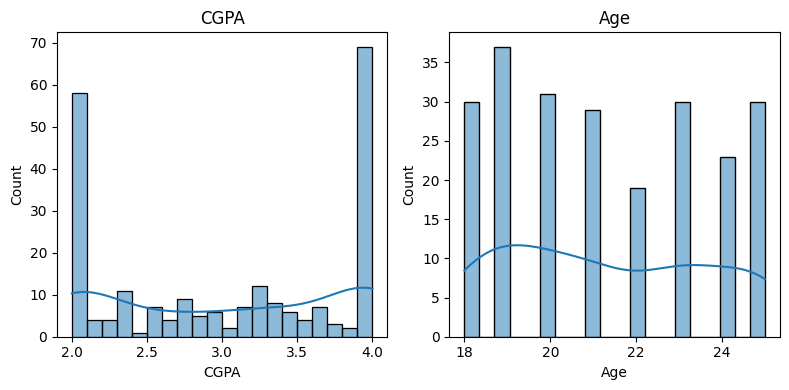

In [8]:

# Définir les colonnes spécifiques à visualiser
Categorical = ['CGPA', 'Age']

# Visualisation des histogrammes pour les variables numériques spécifiées
plt.figure(figsize=(8, 4))
for i, var in enumerate(Categorical, 1):
    plt.subplot(1, 2, i)  # Créer des sous-graphiques pour chaque variable
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f"{var}")
    plt.tight_layout()

plt.show()

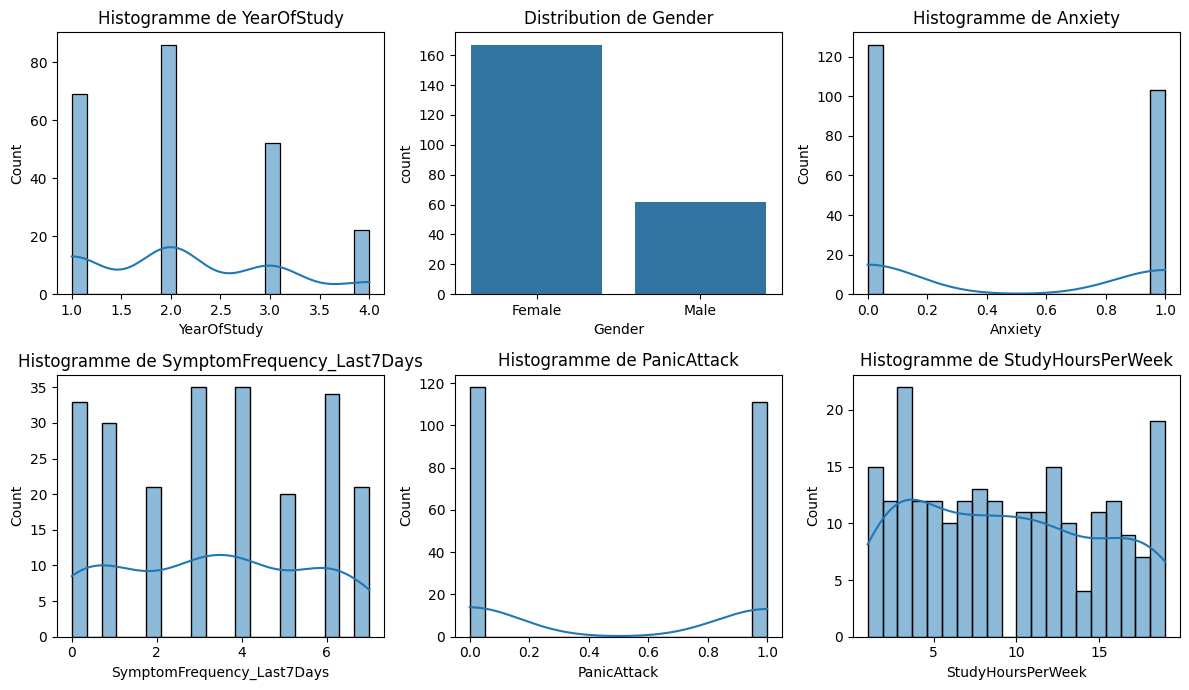

In [9]:
# Définir les colonnes spécifiques à visualiser
# Définir les variables catégorielles et numériques
numériques = ['YearOfStudy', 'Gender', 'Anxiety', 'SymptomFrequency_Last7Days', 'PanicAttack', 'StudyHoursPerWeek']

# Visualisation des variables catégorielles et numériques
plt.figure(figsize=(12, 7))
for i, var in enumerate(numériques, 1):
    plt.subplot(2, 3, i)  # Créer des sous-graphiques (2 lignes, 3 colonnes)

    # Vérifier si la variable est numérique ou catégorielle et afficher en conséquence
    if df[var].dtype in ['int64', 'float64']:  # Si c'est une variable numérique
        sns.histplot(df[var], kde=True, bins=20)
        plt.title(f"Histogramme de {var}")
    else:  # Si c'est une variable catégorielle
        sns.countplot(x=df[var])
        plt.title(f"Distribution de {var}")

    plt.tight_layout()

plt.show()

### **Explications des observations après visualisation :**
La répartition entre les genres : Après avoir observé la distribution des genres dans le dataset, nous pouvons affirmer qu'il y a davantage de femmes que d'hommes. Le graphique en barres de la variable Gender montre une plus grande fréquence pour la catégorie féminine, ce qui suggère une surreprésentation des femmes dans cette étude. Cela peut indiquer des tendances ou des biais dans la collecte des données, ou simplement refléter la composition démographique du groupe étudié.

La répartition des étudiants par année d'études : L'observation des histogrammes pour YearOfStudy nous permet de constater qu'il y a un plus grand nombre d'étudiants en année 2 par rapport aux autres années d'études. Cela pourrait être dû à divers facteurs, comme la taille des cohortes ou la manière dont les étudiants sont répartis au sein de l'université. Il est aussi possible que des étudiants d'autres années aient été moins représentés dans l'échantillon étudié.

Les niveaux d'anxiété dans l'échantillon : En examinant la variable Anxiety, le graphique en barres montre qu'un nombre plus faible de personnes souffrent d'anxiété par rapport à celles qui ne présentent pas de symptômes anxieux. Cela suggère que la majorité des étudiants dans l'échantillon ne rapportent pas de niveaux d'anxiété élevés, ce qui pourrait être interprété comme un signe d'une population relativement équilibrée en termes de santé mentale. Toutefois, cette tendance pourrait être influencée par des biais dans la manière dont l'anxiété est mesurée ou par des facteurs spécifiques à l'échantillon étudié.

Text(0.5, 0.98, 'Comparaison du CGPA selon le Genre et la Dépression')

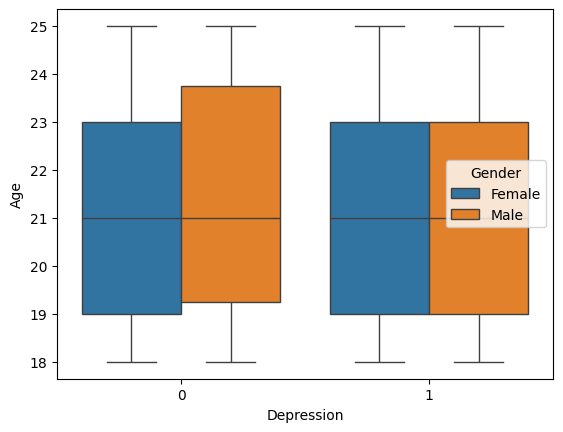

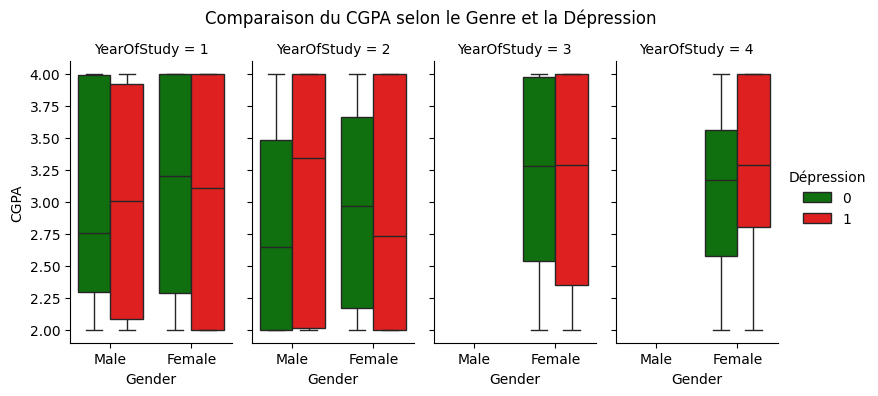

In [10]:
sns.boxplot(x="Depression", y="Age", data=df, hue="Gender")

# Correction de "lette_couleurs" en "palette_couleurs"
palette_couleurs = {1: "red", 0: "green"}
g = sns.FacetGrid(df, col="YearOfStudy", height=4, aspect=.5)
g.map_dataframe(sns.boxplot, x="Gender", y="CGPA", order=["Male", "Female"], hue="Depression", palette=palette_couleurs)

# Ajouter une légende avec un titre
g.add_legend(title="Dépression")

# Ajustement du titre général
plt.subplots_adjust(top=0.85)
g.fig.suptitle("Comparaison du CGPA selon le Genre et la Dépression")

#### 2-1 Appliquez les algorithmes de PCA

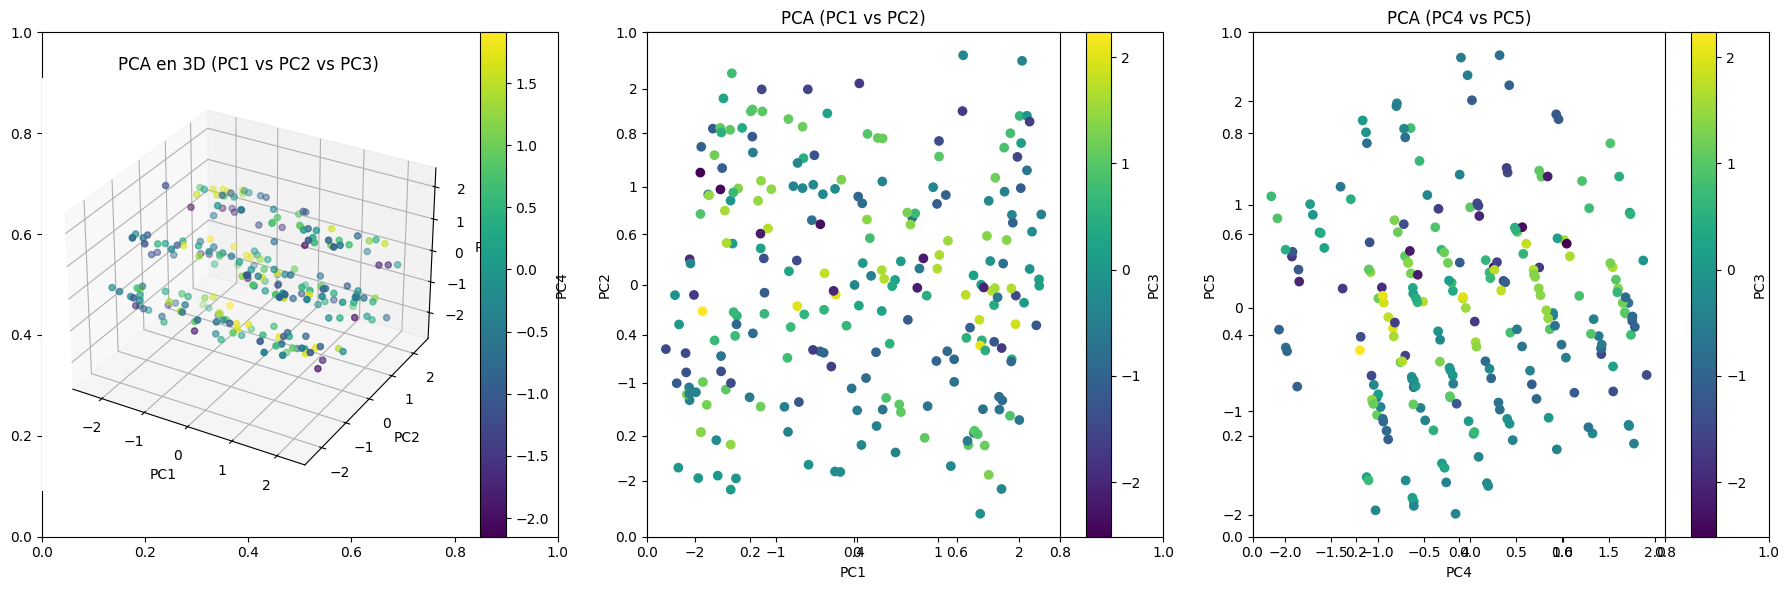

Variance expliquée par PC1: 28.07%
Variance expliquée par PC2: 17.41%
Variance expliquée par PC3: 16.54%
Variance expliquée par PC4: 14.59%
Variance expliquée par PC5: 12.47%
Variance expliquée cumulée: 89.08%


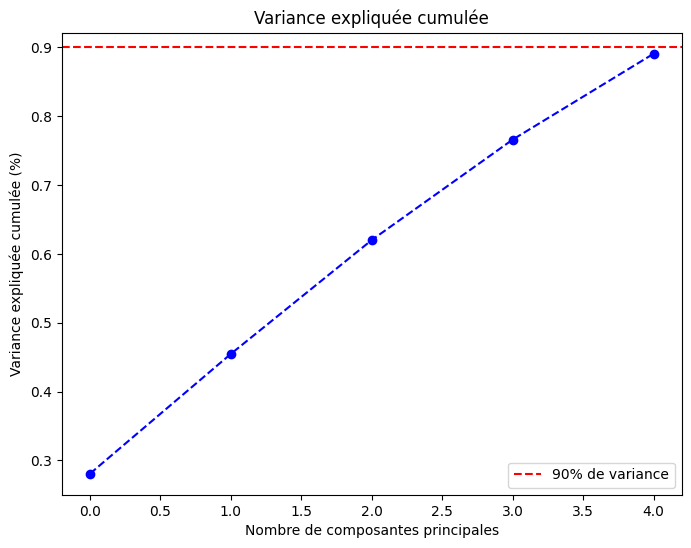

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
# Supposons que 'df' soit votre DataFrame contenant les données
# Sélectionner les variables à utiliser
features = ['Age', 'CGPA', 'Depression', 'Anxiety', "Gender", 'SymptomFrequency_Last7Days', 'StudyHoursPerWeek']

# Convertir les variables catégorielles en variables numériques avec One-Hot Encoding
X = pd.get_dummies(df[features], drop_first=True)

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Appliquer PCA avec 5 composantes principales
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Créer un DataFrame avec les résultats du PCA
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

# Visualisation des résultats PCA en 3D pour les 3 premières composantes principales
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Créer 3 sous-graphiques sur une même ligne

# Premier graphique : PC1 vs PC2 vs PC3 en 3D
ax = fig.add_subplot(131, projection='3d')
sc = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['PC4'], cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA en 3D (PC1 vs PC2 vs PC3)')
fig.colorbar(sc, ax=ax, label='PC4')

# Deuxième graphique : PC1 vs PC2 en 2D
ax2 = fig.add_subplot(132)
scatter2 = ax2.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['PC3'], cmap='viridis')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('PCA (PC1 vs PC2)')
fig.colorbar(scatter2, ax=ax2, label='PC3')

# Troisième graphique : PC4 vs PC5 en 2D
ax3 = fig.add_subplot(133)
scatter3 = ax3.scatter(pca_df['PC4'], pca_df['PC5'], c=pca_df['PC3'], cmap='viridis')
ax3.set_xlabel('PC4')
ax3.set_ylabel('PC5')
ax3.set_title('PCA (PC4 vs PC5)')
fig.colorbar(scatter3, ax=ax3, label='PC3')

# Afficher les graphiques
plt.tight_layout()
plt.show()

# Calcule la variance expliquée par chaque composante principale
explained_variance = pca.explained_variance_ratio_

# Affiche la variance expliquée par chaque composante principale (en pourcentage)
print(f"Variance expliquée par PC1: {explained_variance[0]:.2%}")
print(f"Variance expliquée par PC2: {explained_variance[1]:.2%}")
print(f"Variance expliquée par PC3: {explained_variance[2]:.2%}")
print(f"Variance expliquée par PC4: {explained_variance[3]:.2%}")
print(f"Variance expliquée par PC5: {explained_variance[4]:.2%}")

# Afficher la variance expliquée cumulée en pourcentage
cumulative_variance = np.cumsum(explained_variance)  # Cumul des variances expliquées
print(f"Variance expliquée cumulée: {cumulative_variance[-1]:.2%}")

# Optionnel : Afficher la variance expliquée cumulée sur un graphique
plt.figure(figsize=(8, 6))
plt.plot(cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% de variance')
plt.title('Variance expliquée cumulée')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée (%)')
plt.legend()
plt.show()

L'analyse en composantes principales (PCA) révèle que les cinq premières composantes principales expliquent une proportion importante de la variance des données, avec une variance cumulée de 89.08%. Plus précisément, la première composante principale (PC1) explique 28.07% de la variance, la deuxième (PC2) 17.41%, la troisième (PC3) 16.54%, la quatrième (PC4) 14.59%, et la cinquième (PC5) 12.47%. Cela montre que la majorité de l'information des données peut être capturée par ces cinq composantes, permettant ainsi une réduction de la dimensionnalité tout en conservant une grande partie des informations essentielles. L'avantage de cette approche réside dans sa capacité à simplifier les données, facilitant ainsi leur analyse tout en réduisant le bruit et en améliorant l'efficacité des modèles d'apprentissage automatique, tout en maintenant une grande proportion de la variance originale.

#### **2-2 régression linéaire**

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Sélectionner les features
features = ['Age', 'Depression', 'Gender', 'SymptomFrequency_Last7Days', 'StudyHoursPerWeek']
X = pd.get_dummies(df[features], drop_first=True)

# Définir la variable cible
y = df['CGPA']

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialisation du modèle de régression linéaire
model = LinearRegression()

# Entraînement du modèle
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_test)

# Évaluation du modèle
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Affichage des résultats
print("Résultats pour la Régression Linéaire :")
print(f"Mean Absolute Error: {mea:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Résultats pour la Régression Linéaire :
Mean Absolute Error: 0.2124
Mean Squared Error: 0.0765
Root Mean Squared Error: 0.2766
R-squared: 0.8820


####3- **RandomForestRegressor et XGBoost**
RandomForestRegressor et XGBoost sont deux algorithmes de machine learning très populaires pour les tâches de régression. Le RandomForestRegressor fonctionne en construisant de nombreux arbres de décision, puis en combinant leurs résultats pour obtenir des prédictions plus précises et robustes, tout en réduisant le risque de surapprentissage. Quant à XGBoost, il s'appuie sur le principe du boosting, où plusieurs modèles faibles sont créés successivement pour corriger les erreurs des prédictions précédentes. Cela permet d'améliorer la précision et la rapidité de l'algorithme grâce à des techniques comme la régularisation et le traitement parallèle. Ensemble, ces deux algorithmes offrent des approches complémentaires pour améliorer la performance des modèles de régression, en adressant efficacement la variance et le biais.

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
import xgboost as xgb

# Sélectionner les features
features = ['Age', 'Depression', 'Gender', 'SymptomFrequency_Last7Days', 'StudyHoursPerWeek']
X = pd.get_dummies(df[features], drop_first=True)

# Définir la variable cible
y = df['CGPA']


# Preparation du model
models = {
    'Random Forest Regressor': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(),
}


# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entraînement et évaluation des modèles
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mea = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'Mean Absolute Error': mea,
        'Mean Squared Error': mse,
        'Root Mean Squared Error': rmse,
        'R-squared': r2
    }


# Affichage des résultats
for model_name, metrics in results.items():
    print(f"Résultats pour {model_name} :")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")
    print("\n")





Résultats pour Random Forest Regressor :
Mean Absolute Error: 0.1640
Mean Squared Error: 0.0777
Root Mean Squared Error: 0.2788
R-squared: 0.8802


Résultats pour XGBoost :
Mean Absolute Error: 0.1910
Mean Squared Error: 0.0978
Root Mean Squared Error: 0.3128
R-squared: 0.8492




Ces résultats montrent que le modèle Random Forest Regressor a une performance légèrement meilleure en termes de MAE, MSE, RMSE et R-squared comparé à XGBoost.

#### 4- Comparaison détaillée des modèles de régression


In [66]:
features = ['Age', 'Depression', 'Gender', 'SymptomFrequency_Last7Days', 'StudyHoursPerWeek']
X = pd.get_dummies(df[features], drop_first=True)
y = df['CGPA']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialiser les modèles
models = {
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(),
    'Régression Linéaire': LinearRegression()
}

# Entraîner et évaluer les modèles
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = {
        'MAE/(erreur moyenne)': mae,
        'MSE/(grandes erreurs)': mse,
        'RMSE/(interprétation)': rmse,
        'R²/(qualité du modèle)': r2
    }

# Convertir les résultats en DataFrame
data_result_regression = pd.DataFrame(results).T

# Renommer les colonnes pour une meilleure lisibilité
data_result_regression.columns = [
  'MAE/(erreur moyenne)',
  'MSE/(grandes erreurs)',
  'RMSE/(interprétation)',
  'R²/(qualité du modèle)'
  ]

# Afficher le tableau
data_result_regression


,MAE/(erreur moyenne),MSE/(grandes erreurs),RMSE/(interprétation),R²/(qualité du modèle)
Random Forest Regressor,0.169323,0.080894,0.284419,0.875316
XGBoost,0.191022,0.097829,0.312776,0.849213
Régression Linéaire,0.212442,0.076533,0.276647,0.882037


### **Interprétation des résultats**


1.   Comparaison de la MAE (Mean Absolute Error)
*  Random Forest a la plus petite erreur absolue (0.169323), ce qui signifie que, en moyenne, ses prédictions sont les plus proches des vraies valeurs.
* La régression linéaire a la plus grande erreur absolue (0.212442), ce qui montre qu'elle fait plus d'erreurs en moyenne.
* XGBoost est intermédiaire (0.191022), mais moins performant que Random Forest.

2.  Comparaison du MSE (Mean Squared Error) et RMSE
* Le MSE de la régression linéaire est le plus bas (0.076533), ce qui indique qu’elle est moins sensible aux grandes erreurs que XGBoost et légèrement meilleure que Random Forest.
* Comme le RMSE suit la même tendance que le MSE, la régression linéaire a la meilleure interprétation de l’erreur moyenne (0.2766), suivie de Random Forest (0.284419) et enfin XGBoost (0.31277).

3. Comparaison du R² (coefficient de détermination)
* La régression linéaire a le meilleur R² (0.8820), ce qui signifie qu'elle explique 88,2% de la variance des données.
* Random Forest est juste derrière avec 88,02% de variance expliquée.
* XGBoost est légèrement moins performant, expliquant 84,92% de la variance.

In [61]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# # Sélectionner les features et la cible
# features = ['Age', 'CGPA','Gender', 'SymptomFrequency_Last7Days', 'StudyHoursPerWeek']
# X = pd.get_dummies(df[features], drop_first=True)
# y = df['Depression']

# # Séparer les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Initialiser les modèles
# models = {
#     'Random Forest Classifier': RandomForestClassifier(random_state=42),
#     'XGBoost Classifier': XGBClassifier(random_state=42),
#     'Logistic Regression': LogisticRegression(random_state=42)
# }

# # Entraîner et évaluer les modèles
# results = {}
# for model_name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilités pour ROC-AUC

#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall = recall_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred)
#     roc_auc = roc_auc_score(y_test, y_pred_proba)

#     results[model_name] = {
#         'Accuracy ↑ (exactitude)': accuracy,
#         'Precision ↑ (précision)': precision,
#         'Recall ↑ (rappel)': recall,
#         'F1-score ↑ (équilibre)': f1,
#         'ROC-AUC ↑ (performance)': roc_auc
#     }


#     # Convertir les résultats en DataFrame
# data_result_classification = pd.DataFrame(results).T

# # Renommer les colonnes pour une meilleure lisibilité
# data_result_classification.columns = [
#     'Accuracy ↑ (exactitude)',
#     'Precision ↑ (précision)',
#     'Recall ↑ (rappel)',
#     'F1-score ↑ (équilibre)',
#     'ROC-AUC ↑ (performance)'
# ]

# # Afficher le tableau
# data_result_classification

#### **4- Quel algorithme capture mieux la variance entre les données ?**
Analyse des R² :
Régression Linéaire : R² = 0.882037

Random Forest Regressor : R² = 0.875316

XGBoost : R² = 0.849213

La Régression Linéaire capture mieux la variance entre les données, car elle a le R² le plus élevé (0.882037). Cela signifie qu'elle explique environ 88,2 % de la variance dans la variable cible, ce qui est légèrement meilleur que les autres modèles.

 #### **5- Quels sont les avantages et les inconvénients des algorithmes utilisés pour vos données ?**

 1. Random Forest Regressor
 **Avantages :**
 * Robustesse : Peut gérer des données bruyantes et des valeurs manquantes sans nécessiter de prétraitement complexe.

* Non-linéarité : Capture les relations non linéaires entre les variables explicatives et la cible.

* Interprétabilité partielle : Permet de mesurer l'importance des variables grâce à la fonction feature_importances_.

* Résistance au surajustement (overfitting) : Grâce à l'agrégation de plusieurs arbres de décision, il réduit le risque de surajustement.

* Performances : Généralement très performant sur des données structurées et tabulaires.

**Inconvénients :**

* Temps d'entraînement : Peut être lent à entraîner sur de grands ensembles de données.

* Complexité : Moins interprétable qu'un modèle linéaire simple.

* Mémoire : Nécessite plus de mémoire que des modèles plus simples en raison du grand nombre d'arbres.

* Extrapolation limitée : Moins performant pour prédire des valeurs en dehors de la plage des données d'entraînement.


2. XGBoost (Extreme Gradient Boosting)
**Avantages :**
* Performances élevées : Souvent considéré comme l'un des meilleurs algorithmes pour les compétitions de machine learning en raison de sa précision.

* Gestion des valeurs manquantes : Peut gérer les valeurs manquantes sans prétraitement.

* Flexibilité : Prend en charge la régularisation (L1 et L2) pour éviter le surajustement.

* Interprétabilité partielle : Permet de mesurer l'importance des variables.

* Optimisation : Utilise des techniques avancées comme le gradient boosting et le calcul parallèle pour accélérer l'entraînement.

**Inconvénients :**
* Complexité : Plus difficile à interpréter qu'un modèle linéaire.

* Temps d'entraînement : Peut être lent sur de très grands ensembles de données, bien que plus rapide que Random Forest grâce à l'optimisation.

* Hyperparamètres : Nécessite un réglage minutieux des hyperparamètres pour obtenir les meilleures performances.

* Extrapolation limitée : Comme Random Forest, il est moins performant pour prédire des valeurs en dehors de la plage des données d'entraînement

3. Régression Linéaire
**Avantages :**
* Simplicité : Facile à comprendre, à implémenter et à interpréter.

* Rapidité : Très rapide à entraîner, même sur de grands ensembles de données.

* Interprétabilité : Les coefficients du modèle fournissent des informations directes sur l'importance et la direction des variables.

* Extrapolation : Peut extrapoler des valeurs en dehors de la plage des données d'entraînement (si la relation linéaire est valide).

* Efficacité sur des données linéaires : Très performant lorsque les relations entre les variables sont linéaires.

**Inconvénients :**
* Hypothèse de linéarité : Suppose que la relation entre les variables explicatives et la cible est linéaire, ce qui n'est pas toujours le cas.

* Sensible aux outliers : Les valeurs aberrantes peuvent fortement influencer les résultats.

* Limité aux données linéaires : Ne capture pas les relations non linéaires ou complexes.

* Prétraitement nécessaire : Nécessite souvent une normalisation des données et une gestion des valeurs manquantes.


#### **6-Vérifiez les déséquilibres dans les ensembles de données**
Pour analyser le déséquilibre dans la distribution de la variable cible (y), nous devons examiner :

* Présence d’outliers → valeurs extrêmes qui influencent le modèle.
* Distribution asymétrique → forte concentration des valeurs dans une plage spécifique.
* Problèmes de variance → certaines valeurs de y sont surreprésentées.

#### 6-1 Présence d’outliers

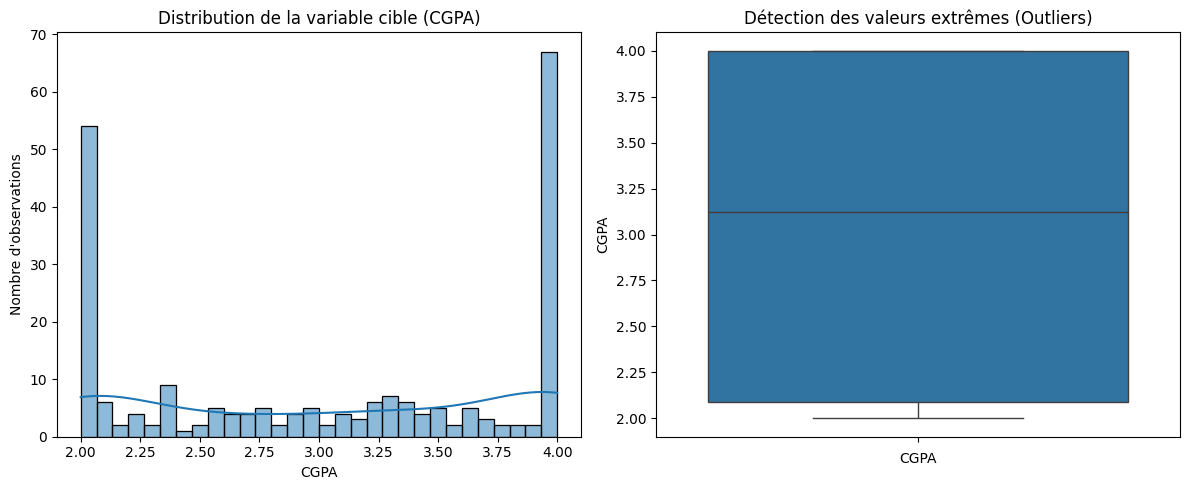

,CGPA
count,229.000000
mean,3.042271
std,0.807088
min,2.000000
25%,2.090000
50%,3.120000
75%,4.000000
max,4.000000


In [77]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))  # 1 ligne, 2 colonnes

# Histogramme
sns.histplot(y, bins=30, kde=True, ax=axes[0])
axes[0].set_xlabel("CGPA")
axes[0].set_ylabel("Nombre d'observations")
axes[0].set_title("Distribution de la variable cible (CGPA)")

# Boxplot
sns.boxplot(y=y, ax=axes[1])
axes[1].set_xlabel("CGPA")
axes[1].set_title("Détection des valeurs extrêmes (Outliers)")

plt.tight_layout()
plt.show()

#  Vérification des Statistiques de y
y.describe()

### **7-Interprétation des résultats :**
**Moyenne et Médiane :**
* La moyenne (3.0423) et la médiane (3.1200) sont relativement proches, ce qui suggère que la distribution de y est relativement symétrique, sans grande asymétrie.

**Écart-type :**
* L'écart-type (0.8071) indique qu'il y a une certaine dispersion autour de la moyenne, mais il n'est pas excessivement élevé, ce qui signifie que la majorité des valeurs sont concentrées autour de la moyenne.
**Min et Max :**
* La valeur minimale (2.0000) et la valeur maximale (4.0000) montrent que CGPA reste dans une plage relativement restreinte. Cependant, si une très grande proportion des valeurs est concentrée à 4.0, il pourrait y avoir un léger déséquilibre dans la distribution, où la majorité des étudiants ont un CGPA élevé.

**Quartiles (25%, 50%, 75%) :**
* 25% des étudiants ont un CGPA inférieur à 2.09, tandis que 75% ont un CGPA inférieur à 4.0. Cela montre que la majorité des étudiants sont concentrés dans la plage supérieure du CGPA, avec peu de valeurs faibles.

#### **8- Identifiez les situations où les algorithmes pourraient échouer ou fournir des résultats inexacts.**

**Biais dans les Données (Biais d’échantillonnage)**
* Problème : Si les données sont biaisées ou non représentatives de la population cible, le modèle ne pourra pas faire des prédictions générales précises.
* Pourquoi ? Un échantillon biaisé peut rendre le modèle sur-adapté à un sous-ensemble de données et donc inefficace pour des données non observées.

**Mauvais Choix de Modèle pour le Problème**
* Problème : Utiliser un modèle non adapté pour la tâche spécifique. Par exemple, la régression linéaire est souvent utilisée par défaut, mais elle peut échouer dans des cas où une relation non-linéaire ou un comportement complexe est attendu.
*Pourquoi ? La régression linéaire fait des hypothèses strictes, comme la normalité des résidus et la linéarité de la relation entre les variables d'entrée et la cible.

**Données Déséquilibrées (Régression avec des plages étroites de valeurs cibles)**
* Problème : Si les valeurs cibles sont trop concentrées autour d'une plage étroite, ou si certaines valeurs cibles sont rares (par exemple, un petit nombre de valeurs faibles dans un modèle de régression du CGPA), cela peut fausser les résultats.
* Pourquoi ? Les modèles peuvent être influencés de manière disproportionnée par la plage où les données sont plus denses, réduisant ainsi la capacité du modèle à prédire avec précision les autres valeurs.